<a href="https://colab.research.google.com/github/ValleyFarell/DockerHW/blob/main/%D0%9E%D0%BA%D0%BA%D0%B0%D0%BC%D0%B0%2C_%D0%BF%D1%80%D0%BE%D0%B2%D0%B5%D1%80%D0%BA%D0%B0_%D0%B3%D0%B8%D0%BF%D0%BE%D1%82%D0%B5%D0%B7%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Исследование переобучения и байесовский выбор модели

## 1. Введение и постановка задачи

**Переобучение (overfitting)** — это фундаментальная проблема машинного обучения, при которой модель начинает «заучивать» шум в обучающих данных вместо поиска истинных закономерностей. В результате ошибка на обучающей выборке стремится к нулю, но на новых данных модель показывает крайне низкую точность.

Эта проблема неразрывно связана с **дилеммой смещения и дисперсии (bias-variance tradeoff)**:
*   **Высокое смещение (Underfitting):** модель слишком проста, чтобы уловить структуру данных.
*   **Высокая дисперсия (Overfitting):** модель избыточно сложна и крайне чувствительна к малейшим изменениям в данных.

Согласно принципу **бритвы Оккама**, из множества гипотез, одинаково хорошо объясняющих данные, следует выбирать самую простую. В этом эксперименте мы наглядно продемонстрируем, как сложность модели (степень полинома) влияет на её обобщающую способность.

## 2. Генерация данных

Для эксперимента мы генерируем синтетический набор данных. В качестве целевой зависимости выбрана квадратичная функция с добавлением случайного гауссовского шума:

$$y_i = x_i^2 + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \sigma^2)$$

**Параметры генерации:**
*   Объём выборки: $N=50$ точек.
*   Распределение $x$: мы намеренно создаем «дыру» (область с редкими данными) в интервале $[-0.6, 0.6]$, чтобы увидеть, как ведут себя сложные модели в условиях недостатка информации.
*   Данные разделяются на тренировочные и тестовые для оценки качества предсказания.

## 3. Обучение моделей

Мы рассматриваем семейство моделей полиномиальной регрессии степени $d$:

$$f_d(x) = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d = \sum_{k=0}^{d} w_k x^k$$

Коэффициенты модели $w$ определяются методом **минимизации среднеквадратичной ошибки (MSE)**. В байесовском подходе мы вводим априорные распределения (priors) на веса:

$$w_k \sim \mathcal{N}(0, \sigma_w^2)$$

Это эквивалентно $L_2$-регуляризации (Ridge regression). Стоит отметить, что при очень высоких степенях ($d \geq n$) задача становится недоопределенной, и классический МНК может давать неустойчивые решения.

## 4. Результаты и визуализация

Анализ полученных графиков позволяет сделать следующие выводы:
1.  **Полином низкой степени (d=2, 4):** хорошо улавливает общую тенденцию данных и сохраняет стабильность в «пустой» области.
2.  **Полином высокой степени (d=10 и выше):** демонстрирует классическое переобучение. Кривая проходит точно через зашумленные точки обучающей выборки, но совершает дикие осцилляции в промежутках между ними (особенно в области «дыры»).
3.  **Регуляризация (Ridge):** добавление штрафа на норму весов сглаживает кривую даже для сложных моделей, не позволяя коэффициентам принимать экстремально большие значения.

## 5. Байесовская интерпретация (Bayesian Evidence)

Центральный момент эксперимента — понимание того, почему байесовский подход естественным образом реализует бритву Оккама. Мы рассматриваем апостериорное распределение параметров $p(w|D)$.

Для **простой модели** (малое $d$) параметров немного, и данные быстро «стягивают» априорное распределение к узкому пику. Для **сложной модели** существует бесконечное множество комбинаций весов, которые дают нулевую ошибку на данных (overfitting). В результате апостериорное распределение «размазывается» по этому многообразию.

Это отражается в величине **Evidence (Marginal Likelihood)**:

$$p(D|M) = \int p(D|w, M) p(w|M) dw$$

Сложная модель $M_{complex}$ обладает огромным пространством параметров, и её априорная плотность $p(w|M)$ распределена очень тонким слоем. Несмотря на то, что она может идеально объяснить данные ($p(D|w, M) \approx 1$), интеграл по всему пространству параметров оказывается меньше, чем у простой модели, чья априорная масса сконцентрирована в нужной области. Это и есть **Байесовская бритва Оккама**.

## 6. Выводы

*   Оптимальная сложность модели для данных $y=x^2$ лежит в районе степеней 2–4. Дальнейшее усложнение ведет к росту дисперсии без улучшения качества.
*   **Регуляризация** — необходимый инструмент для контроля переобучения, позволяющий эффективно использовать сложные модели.
*   Выбор модели — это всегда **компромисс (tradeoff)** между точностью аппроксимации и простотой. Практическим инструментом такого выбора является кросс-валидация или расчет информационных критериев (WAIC, LOO).

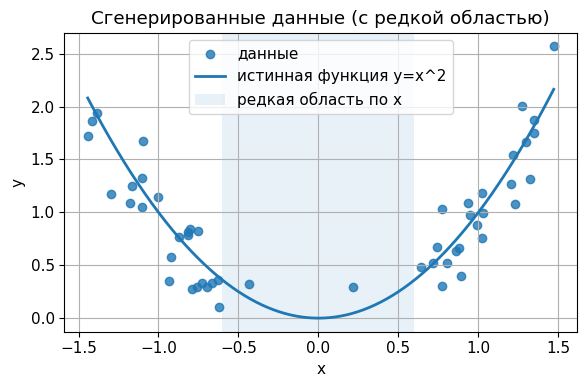


Строим модель для полинома степени 4...


Output()


Строим модель для полинома степени 10...


Output()


Краткие сводки trace (R-hat, ESS и т.п.):

Степень 4:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.155,0.141,-0.118,0.408,0.004,0.003,1408.0,1908.0,1.0
w[1],-0.015,0.094,-0.189,0.165,0.003,0.002,1414.0,1857.0,1.0
w[2],0.593,0.279,0.058,1.101,0.008,0.006,1310.0,1585.0,1.0
w[3],0.044,0.067,-0.083,0.166,0.002,0.001,1400.0,1681.0,1.0
w[4],0.153,0.119,-0.071,0.377,0.003,0.002,1336.0,1801.0,1.0
sigma,0.255,0.028,0.208,0.311,0.001,0.001,2108.0,2316.0,1.0



Степень 10:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.198,0.183,-0.137,0.548,0.003,0.003,2892.0,2332.0,1.0
w[1],0.205,0.272,-0.268,0.749,0.006,0.005,2256.0,2283.0,1.0
w[2],0.302,0.575,-0.797,1.351,0.012,0.011,2416.0,2353.0,1.0
w[3],-0.246,0.635,-1.409,0.977,0.014,0.011,2115.0,2388.0,1.0
w[4],0.524,0.739,-0.911,1.883,0.015,0.014,2348.0,1920.0,1.0
w[5],-0.099,0.723,-1.444,1.270,0.016,0.013,1999.0,2245.0,1.0
w[6],0.176,0.760,-1.263,1.619,0.017,0.014,2097.0,2190.0,1.0
w[7],0.156,0.550,-0.864,1.184,0.013,0.009,1831.0,2275.0,1.0
w[8],-0.377,0.562,-1.471,0.623,0.012,0.011,2059.0,1967.0,1.0
w[9],-0.027,0.148,-0.311,0.237,0.003,0.002,2088.0,2336.0,1.0


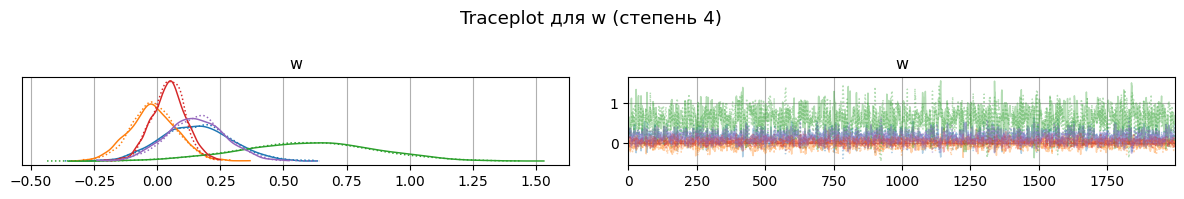

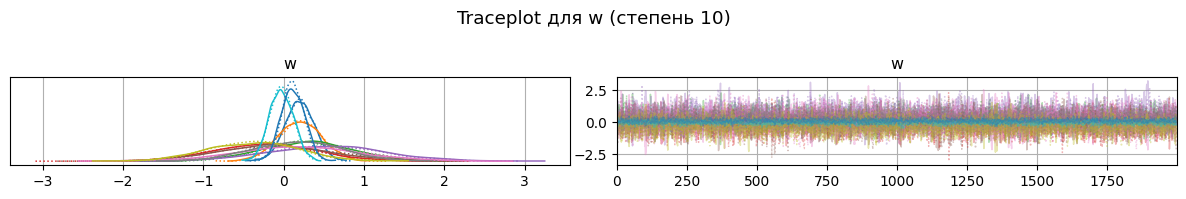

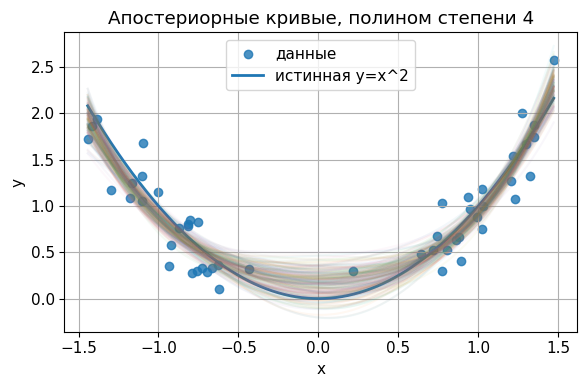

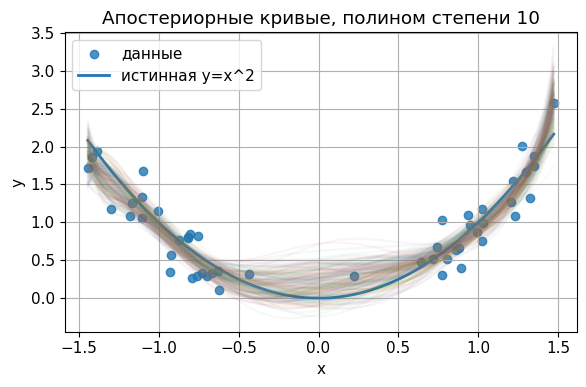

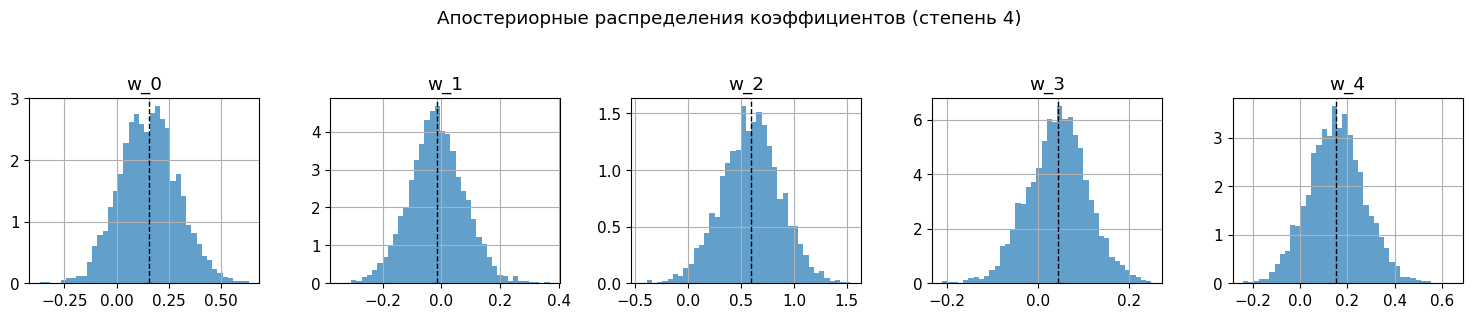

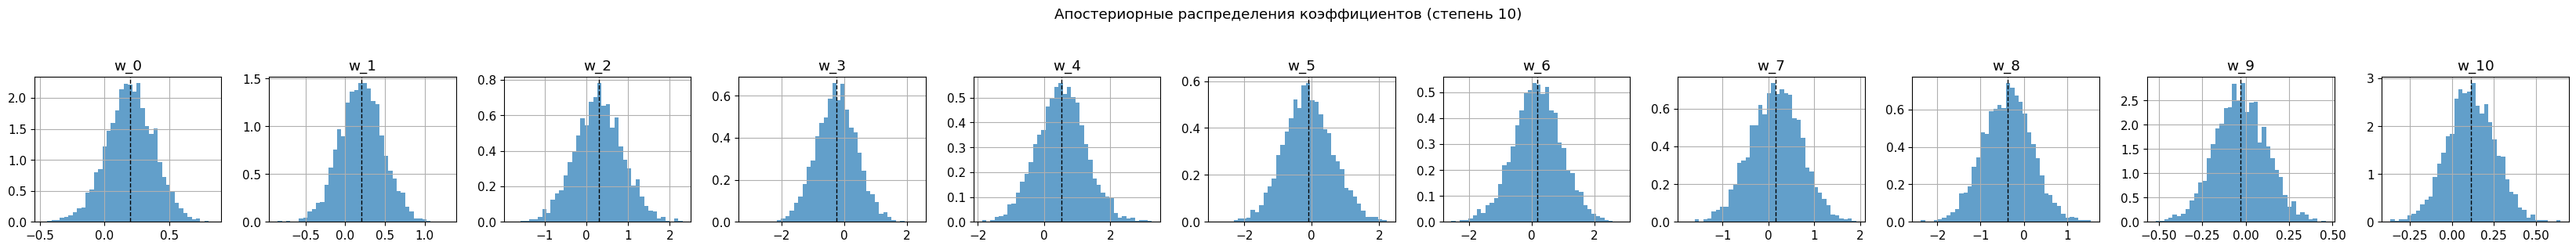


=== Моды для полинома степени 4 ===
Число компонент GMM (оценка числа мод): 1

  Мода #1
    Вес компоненты (апост. масса кластера): 1.000
    Первые коэффициенты: [ 0.15476966 -0.01540224  0.59349974  0.04445298] ...
    Flatness (среднее собств. знач.): 2.500e-02
    det(cov): 4.400e-13

=== Моды для полинома степени 10 ===
Число компонент GMM (оценка числа мод): 1

  Мода #1
    Вес компоненты (апост. масса кластера): 1.000
    Первые коэффициенты: [ 0.19806222  0.20473967  0.30157056 -0.24644013] ...
    Flatness (среднее собств. знач.): 2.863e-01
    det(cov): 5.922e-23


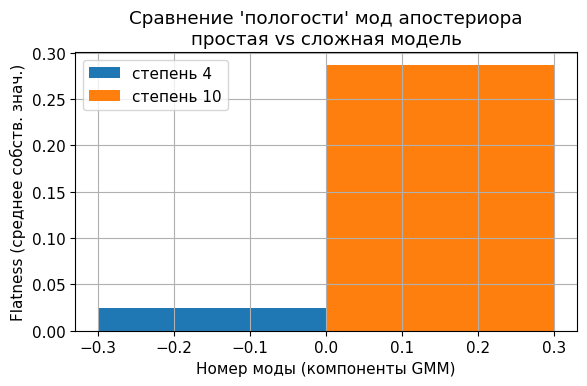


Готово. Можешь теперь играться с degree_complex и параметрами 'дыры' в данных.


In [ ]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from IPython.display import display  # для az.summary в коллабе

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# 1. Генерация данных с "дырой" по x
def generate_data(
    n_points=40,
    noise_sigma=0.3,
    random_state=42,
    x_min=-1.5,
    x_max=1.5,
    hole_interval=(-0.3, 0.3),
    hole_fraction=0.2,
):
    """
    Генерируем точки так, чтобы в интервале hole_interval было сильно меньше x.

    hole_fraction — доля точек, которая попадает внутрь "дыры".
    Остальные точки равномерно распределены по двум кускам: [x_min, left] и [right, x_max].
    """
    rng = np.random.default_rng(random_state)
    hole_left, hole_right = hole_interval

    # кол-во точек внутри "дыры"
    n_hole = max(1, int(n_points * hole_fraction))
    n_rest = n_points - n_hole
    if n_rest < 2:
        n_rest = 2
        n_hole = max(1, n_points - n_rest)

    # точки снаружи дыры
    n_left = n_rest // 2
    n_right = n_rest - n_left

    x_left = rng.uniform(x_min, hole_left, size=n_left)
    x_right = rng.uniform(hole_right, x_max, size=n_right)

    # точки внутри дыры (их меньше)
    x_hole = rng.uniform(hole_left, hole_right, size=n_hole)

    x = np.concatenate([x_left, x_right, x_hole])
    rng.shuffle(x)

    y_true = x**2
    y = y_true + rng.normal(0, noise_sigma, size=x.shape[0])

    return x, y, y_true, hole_interval


# 2. Байесовская полиномиальная модель
def build_poly_model(x, y, degree, w_sigma=1.0, noise_sigma_prior=1.0):
    """
    y_i ~ Normal( sum_{k=0}^d w_k x_i^k, sigma )

    Priors:
      w_k ~ Normal(0, w_sigma)
      sigma ~ HalfNormal(noise_sigma_prior)
    """
    X = np.vstack([x**k for k in range(degree + 1)]).T  # (N, degree+1)

    with pm.Model() as model:
        w = pm.Normal("w", mu=0.0, sigma=w_sigma, shape=(degree + 1,))
        sigma = pm.HalfNormal("sigma", sigma=noise_sigma_prior)

        mu = pm.math.dot(X, w)
        pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    return model


# 3. Сэмплирование апостериора
def sample_posterior(model, draws=2000, tune=2000, target_accept=0.95, random_seed=42):
    with model:
        trace = pm.sample(
            draws=draws,
            tune=tune,
            target_accept=target_accept,
            random_seed=random_seed,
            chains=2,
            cores=2,
            progressbar=True,
        )
    return trace


# 4. Достаём w из trace максимально надёжно
def get_w_samples(trace):
    """
    Возвращает numpy-массив формы (n_samples, n_coeffs)
    для w из trace.posterior["w"].

    Обычный случай PyMC: shape = (n_chains, n_draws, n_coeffs).
    """
    w = trace.posterior["w"].values

    if w.ndim == 3:
        n_chains, n_draws, n_coeffs = w.shape
        w = w.reshape(n_chains * n_draws, n_coeffs)
        return w

    if w.ndim == 2:
        # fallback: уже (n_samples, n_coeffs)
        return w

    raise ValueError(f"Неожиданная форма массива w: {w.shape}")


# 5. Визуализация

def plot_data_and_true(x, y, y_true, hole_interval=None):
    """
    Рисуем:
      - точки данных (как есть, с их реальными x)
      - гладкую истинную кривую y = x^2 на равномерной сетке x_plot
    """
    # Сетка для красивой кривой
    x_plot = np.linspace(x.min(), x.max(), 400)
    y_true_plot = x_plot**2  # истинная функция

    plt.figure()
    # данные — только scatter, без соединения
    plt.scatter(x, y, label="данные", alpha=0.8)

    # истинная кривая — по ровной сетке
    plt.plot(x_plot, y_true_plot, label="истинная функция y=x^2", linewidth=2)

    if hole_interval is not None:
        hole_left, hole_right = hole_interval
        plt.axvspan(hole_left, hole_right, alpha=0.1, label="редкая область по x")

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Сгенерированные данные (с редкой областью)")
    plt.legend()
    plt.tight_layout()
    plt.show()



def posterior_predictive_plot(x, y, y_true, trace, degree, n_curves=200):
    """
    Рисуем:
      - точки данных
      - истинную кривую y=x^2 на равномерной сетке
      - семейство апостериорных кривых тоже на этой сетке

    ВАЖНО: кривые строятся не по тренировочным x (которые перемешаны),
           а по гладкой сетке x_plot, чтобы не было ломаных.
    """
    # Сетка для картинки
    x_plot = np.linspace(x.min(), x.max(), 400)
    X_plot = np.vstack([x_plot**k for k in range(degree + 1)]).T  # (N_plot, degree+1)

    # Семплы коэффициентов
    w_samples = get_w_samples(trace)  # (n_samples, degree+1)

    # подвыборка
    n_total = w_samples.shape[0]
    n_curves = min(n_curves, n_total)
    idx = np.linspace(0, n_total - 1, n_curves, dtype=int)
    w_samples = w_samples[idx, :]

    plt.figure()
    # данные остаются как есть
    plt.scatter(x, y, label="данные", alpha=0.8)

    # истинная кривая на сетке
    y_true_plot = x_plot**2
    plt.plot(x_plot, y_true_plot, label="истинная y=x^2", linewidth=2)

    # апостериорные кривые
    for w in w_samples:
        y_pred = X_plot @ w
        plt.plot(x_plot, y_pred, alpha=0.05)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Апостериорные кривые, полином степени {degree}")
    plt.legend()
    plt.tight_layout()
    plt.show()



def plot_coeff_posteriors(trace, degree):
    """
    1D-гистограммы/плотности для коэффициентов w_k.
    """
    w_samples = get_w_samples(trace)
    n_coeffs = degree + 1

    fig, axes = plt.subplots(1, n_coeffs, figsize=(3 * n_coeffs, 3))
    if n_coeffs == 1:
        axes = [axes]

    for k in range(n_coeffs):
        ax = axes[k]
        ax.hist(w_samples[:, k], bins=40, density=True, alpha=0.7)
        ax.set_title(f"w_{k}")
        ax.axvline(np.mean(w_samples[:, k]), color="k", linestyle="--", linewidth=1)
    fig.suptitle(f"Апостериорные распределения коэффициентов (степень {degree})", y=1.05)
    plt.tight_layout()
    plt.show()


def traceplot_w(trace, degree):
    az.plot_trace(trace, var_names=["w"])
    plt.suptitle(f"Traceplot для w (степень {degree})")
    plt.tight_layout()
    plt.show()


# 6. GMM по w — моды апостериора

def choose_gmm_components(samples, max_components=6, random_state=42):
    lowest_bic = np.inf
    best_gmm = None
    best_k = None
    for k in range(1, max_components + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            random_state=random_state,
        )
        gmm.fit(samples)
        bic = gmm.bic(samples)
        if bic < lowest_bic:
            lowest_bic = bic
            best_gmm = gmm
            best_k = k
    return best_gmm, best_k, lowest_bic


def analyze_modes(samples, max_components=6, random_state=42):
    gmm, k_best, bic_best = choose_gmm_components(samples, max_components, random_state)

    means = gmm.means_
    covs = gmm.covariances_
    weights = gmm.weights_

    flatness = []
    for C in covs:
        eigvals = np.linalg.eigvalsh(C)
        flatness.append(np.mean(eigvals))
    flatness = np.array(flatness)

    return {
        "gmm": gmm,
        "n_components": k_best,
        "bic": bic_best,
        "means": means,
        "covs": covs,
        "weights": weights,
        "flatness": flatness,
    }


def print_modes_summary(info, degree):
    means = info["means"]
    covs = info["covs"]
    weights = info["weights"]
    flatness = info["flatness"]

    print(f"\n=== Моды для полинома степени {degree} ===")
    print(f"Число компонент GMM (оценка числа мод): {info['n_components']}")
    for i, (w, m, C, f) in enumerate(zip(weights, means, covs, flatness)):
        detC = np.linalg.det(C)
        print(f"\n  Мода #{i+1}")
        print(f"    Вес компоненты (апост. масса кластера): {w:.3f}")
        print(f"    Первые коэффициенты: {m[:4]}{' ...' if len(m) > 4 else ''}")
        print(f"    Flatness (среднее собств. знач.): {f:.3e}")
        print(f"    det(cov): {detC:.3e}")


def plot_modes_flatness(info_simple, info_complex, degree_simple, degree_complex):
    flat_s = info_simple["flatness"]
    flat_c = info_complex["flatness"]

    plt.figure(figsize=(6, 4))
    idx_s = np.arange(len(flat_s))
    idx_c = np.arange(len(flat_c))

    plt.bar(idx_s - 0.15, flat_s, width=0.3, label=f"степень {degree_simple}")
    plt.bar(idx_c + 0.15, flat_c, width=0.3, label=f"степень {degree_complex}")

    plt.xlabel("Номер моды (компоненты GMM)")
    plt.ylabel("Flatness (среднее собств. знач.)")
    plt.title("Сравнение 'пологости' мод апостериора\nпростая vs сложная модель")
    plt.legend()
    plt.tight_layout()
    plt.show()


# 7. Основной эксперимент

def main():
    # --- Задаём степени моделей ---
    degree_simple = 4      # базовая (простая) модель
    degree_complex = 10     # сложная модель; можешь поменять на 6/7/etc

    # --- Данные ---
    x, y, y_true, hole_interval = generate_data(
        n_points=50,
        noise_sigma=0.3,
        hole_interval=(-0.6, 0.6),
        hole_fraction=0.05,
    )
    plot_data_and_true(x, y, y_true, hole_interval=hole_interval)

    # --- Модели ---
    print(f"\nСтроим модель для полинома степени {degree_simple}...")
    model_simple = build_poly_model(x, y, degree=degree_simple, w_sigma=1.0, noise_sigma_prior=1.0)
    trace_simple = sample_posterior(model_simple, draws=2000, tune=2000, target_accept=0.95)

    print(f"\nСтроим модель для полинома степени {degree_complex}...")
    model_complex = build_poly_model(x, y, degree=degree_complex, w_sigma=1.0, noise_sigma_prior=1.0)
    trace_complex = sample_posterior(model_complex, draws=2000, tune=2000, target_accept=0.95)

    # --- Сводка по сэмплам ---
    print("\nКраткие сводки trace (R-hat, ESS и т.п.):")
    print(f"\nСтепень {degree_simple}:")
    display(az.summary(trace_simple, var_names=["w", "sigma"]))
    print(f"\nСтепень {degree_complex}:")
    display(az.summary(trace_complex, var_names=["w", "sigma"]))

    traceplot_w(trace_simple, degree_simple)
    traceplot_w(trace_complex, degree_complex)

    # --- Апостериорные кривые ---
    posterior_predictive_plot(x, y, y_true, trace_simple, degree_simple)
    posterior_predictive_plot(x, y, y_true, trace_complex, degree_complex)

    # --- Распределения коэффициентов ---
    plot_coeff_posteriors(trace_simple, degree_simple)
    plot_coeff_posteriors(trace_complex, degree_complex)

    # --- Моды в пространстве коэффициентов ---
    w_simple = get_w_samples(trace_simple)
    w_complex = get_w_samples(trace_complex)

    max_for_gmm = 5000
    rng = np.random.default_rng(0)

    if w_simple.shape[0] > max_for_gmm:
        idx_s = rng.choice(w_simple.shape[0], max_for_gmm, replace=False)
        w_simple = w_simple[idx_s]
    if w_complex.shape[0] > max_for_gmm:
        idx_c = rng.choice(w_complex.shape[0], max_for_gmm, replace=False)
        w_complex = w_complex[idx_c]

    modes_simple = analyze_modes(w_simple, max_components=5, random_state=42)
    modes_complex = analyze_modes(w_complex, max_components=5, random_state=42)

    print_modes_summary(modes_simple, degree_simple)
    print_modes_summary(modes_complex, degree_complex)

    plot_modes_flatness(modes_simple, modes_complex, degree_simple, degree_complex)

    print("\nГотово. Можешь теперь играться с degree_complex и параметрами 'дыры' в данных.")

if __name__ == "__main__":
    main()
